# Klasifikasi Adopsi Managed Service Provider Menggunakan Algoritma SVM Berbasis Framework TOE Framework

**Notebook untuk Skripsi**  
Dataset Train: Digital Adoption in Telecom Dataset (Kaggle)
Dataset Test : Customer PT. Solusi Jasa Teknologi  
Tujuan: Preprocessing → Feature Selection (TOE) → Training SVM + Tuning → Evaluasi → Generate Report

In [105]:
# 1. Import Library
# Import Library yang dibutuhkan
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

print("✅ Semua library berhasil diimport")

✅ Semua library berhasil diimport


In [130]:
#2. Load Dataset
# Load data training (Kaggle)
df_train = pd.read_csv('telecom_dataset.csv') 
# Load data test SOJATEK
df_test = pd.read_csv('data_test_sjt.csv')

print("✅ Data Training (Kaggle) berhasil dimuat - Shape", df_train.shape)
print("\n✅ Data Test SJT berhasil dimuat - Shape", df_test.shape)
print("Kolom test_sjt:", df_test.columns.tolist())

df_train.head()

✅ Data Training (Kaggle) berhasil dimuat - Shape (2600, 31)

✅ Data Test SJT berhasil dimuat - Shape (42, 8)
Kolom test_sjt: ['PU', 'PEOU', 'TECH', 'ORG', 'ENV', 'Age', 'Experience', 'INT']


,PU1,PEOU1,TECH1,ORG1,ENV1,PU2,PEOU2,TECH2,ORG2,ENV2,...,CUST2,PERF3,CUST3,Age,Experience,Department,Gender,Random_Noise1,Random_Noise2,Unused_Category
0,4.126502,3.835910,2.785725,4.829862,2.020247,3.883523,2.903098,3.029325,4.385431,2.667728,...,3.159067,1.644632,NaN,40.0,NaN,HR,Female,-1.092606,68.0,D
1,NaN,3.643542,3.757881,3.246819,3.721594,3.634645,4.064790,3.161425,2.913873,3.872978,...,2.268892,2.594456,2.213869,28.0,20.0,Operations,Female,0.651919,46.0,A
2,4.482122,4.251888,3.218534,3.582300,3.666302,3.857671,3.726371,4.583807,3.680214,3.655421,...,2.909131,1.710343,3.556857,34.0,6.0,Operations,Male,2.179664,67.0,D
3,4.243509,3.983887,3.898648,3.879527,4.989238,4.451033,3.046086,3.467994,3.506437,4.737414,...,2.357133,2.768777,2.825143,44.0,15.0,NaN,Female,0.700494,24.0,A
4,4.175922,4.108287,3.172487,5.000000,4.372157,4.539167,3.941352,2.657540,4.733467,NaN,...,3.404439,2.550882,3.449773,37.0,23.0,IT,Female,1.310921,71.0,D


In [131]:
#3. Feature Engineering TOE
# Membuat fitur agregat (rata-rata) TOE features
def create_toe_features(df):
    df = df.copy()
    df['PU']   = df[['PU1','PU2','PU3']].mean(axis=1)
    df['PEOU'] = df[['PEOU1','PEOU2','PEOU3']].mean(axis=1)
    df['TECH'] = df[['TECH1','TECH2','TECH3']].mean(axis=1)
    df['ORG']  = df[['ORG1','ORG2','ORG3']].mean(axis=1)
    df['ENV']  = df[['ENV1','ENV2','ENV3']].mean(axis=1)
    return df

df_train = create_toe_features(df_train)
selected_features = ['PU', 'PEOU', 'TECH', 'ORG', 'ENV', 'Age', 'Experience']

print("✅ Fitur TOE agregat berhasil dibuat")
print("Fitur yang digunakan:", selected_features)

✅ Fitur TOE agregat berhasil dibuat
Fitur yang digunakan: ['PU', 'PEOU', 'TECH', 'ORG', 'ENV', 'Age', 'Experience']


In [146]:
#4. Target Variable & Preprocessing
int_cols = ['INT1', 'INT2', 'INT3']
df_train['INT_Avg'] = df_train[int_cols].mean(axis=1)
df_train['Adoption_Level'] = np.where(df_train['INT_Avg'] >= 4.0, 1, 0)

#imputer 
imputer = SimpleImputer(strategy='mean')
selected_features = ['PU', 'PEOU', 'TECH', 'ORG', 'ENV', 'Age', 'Experience']
df_train[selected_features] = imputer.fit_transform(df_train[selected_features])
df_test[selected_features] = imputer.transform(df_test[selected_features])

#Split dulu sebelum SMOTE 
X = df_train[selected_features]
y = df_train['Adoption_Level']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

#MOTE HANYA pada Training Set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

svc = SVC(probability=True,random_state=42)

#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_val_scaled = scaler.transform(X_val)

print("Distribusi Target Training:", df_train['Adoption_Level'].value_counts(normalize=True))
print("Distribusi kelas setelah SMOTE:", pd.Series(y_train_res).value_counts())

Distribusi Target Training: Adoption_Level
0    0.655
1    0.345
Name: proportion, dtype: float64
Distribusi kelas setelah SMOTE: Adoption_Level
0    1362
1    1362
Name: count, dtype: int64


In [158]:
#6. Training SVM + Hyperparameter Tuning (GridSearchCV)
param_grid = {'C': [0.01, 0.1, 1, 10, 50, 100], 'gamma': [0.0001, 0.001, 0.01, 0.1, 1.0, 'scale'], 'kernel': ['rbf']}
grid_search = GridSearchCV(
    SVC(probability=True, random_state=42, class_weight='balanced'), 
    param_grid, 
    cv=10, scoring='recall', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train_res)
best_model = grid_search.best_estimator_
print("Best Params:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Params: {'C': 1, 'gamma': 0.0001, 'kernel': 'rbf'}
Best CV Accuracy: 0.891943967367969



=== EVALUASI VALIDATION SET ===
               precision    recall  f1-score   support

 Low Adoption     0.8670    0.5161    0.6471       341
High Adoption     0.4795    0.8492    0.6129       179

     accuracy                         0.6308       520
    macro avg     0.6732    0.6826    0.6300       520
 weighted avg     0.7336    0.6308    0.6353       520

Accuracy : 0.6308
ROC-AUC  : 0.7654


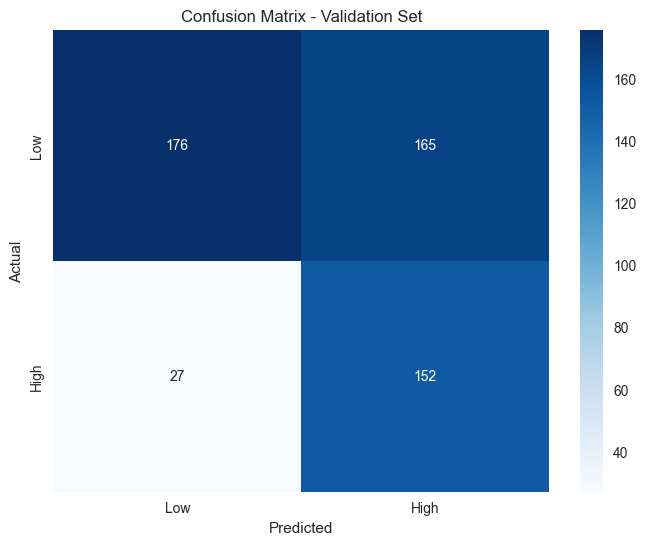


=== TEST SET PT SOLUSI JASA TEKNOLOGI ===
               precision    recall  f1-score   support

 Low Adoption     0.5333    0.8000    0.6400        10
High Adoption     0.9259    0.7812    0.8475        32

     accuracy                         0.7857        42
    macro avg     0.7296    0.7906    0.7437        42
 weighted avg     0.8325    0.7857    0.7981        42

Accuracy : 0.7857
ROC-AUC  : 0.8766


In [176]:
# 7. Evaluasi Model
print("\n=== EVALUASI VALIDATION SET ===")
y_val_pred = best_model.predict(X_val_scaled)
y_val_proba = best_model.predict_proba(X_val_scaled)[:, 1]

print(classification_report(y_val, y_val_pred, digits=4, 
                           target_names=['Low Adoption', 'High Adoption']))
print(f"Accuracy : {accuracy_score(y_val, y_val_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_val, y_val_proba):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.title('Confusion Matrix - Validation Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix_validation.png', dpi=300, bbox_inches='tight')
plt.show()

# Test SJT
X_test = df_test[selected_features]
X_test_scaled = scaler.transform(X_test)
y_test = np.where(df_test['INT'] >= 4.0, 1, 0)

y_test_pred = best_model.predict(X_test_scaled)
y_test_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print("\n=== TEST SET PT SOLUSI JASA TEKNOLOGI ===")
print(classification_report(y_test, y_test_pred, digits=4,
                           target_names=['Low Adoption', 'High Adoption']))
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_proba):.4f}")

In [182]:
#8. Simpan Model, Scaler, dan Imputer
joblib.dump(best_model, 'svm_msp_toe_model.pkl')
joblib.dump(scaler, 'scaler_toe.pkl')
joblib.dump(imputer, 'imputer_toe.pkl')

print("✅ Model, Scaler, dan Imputer berhasil disimpan!")

✅ Model, Scaler, dan Imputer berhasil disimpan!


In [184]:
#9. Fungsi Prediksi Adopsi 
def predict_msp_adoption(input_dict):
    input_df = pd.DataFrame([input_dict])
    input_imputed = imputer.transform(input_df)
    input_scaled = scaler.transform(input_imputed)
    pred = best_model.predict(input_scaled)[0]
    proba = best_model.predict_proba(input_scaled)[0][1]
    result = "High Adoption" if pred == 1 else "Low Adoption"
    return result, round(proba, 4)

# Contoh
sample = {'PU':4.4, 'PEOU':5, 'TECH':4.8, 'ORG':4, 'ENV':4, 'Age':30, 'Experience':12}
hasil, prob = predict_msp_adoption(sample)
print(f"Prediksi: {hasil}")
print(f"Probability: {prob*100:.2f}%")

Prediksi: High Adoption
Probability: 66.24%
